Model training completed.


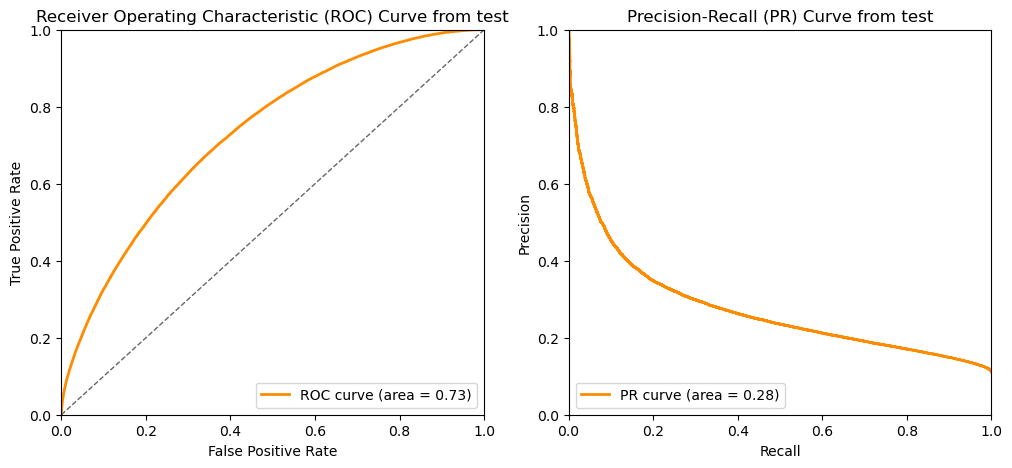

AUROC: 0.7313
AUPRC: 0.2755


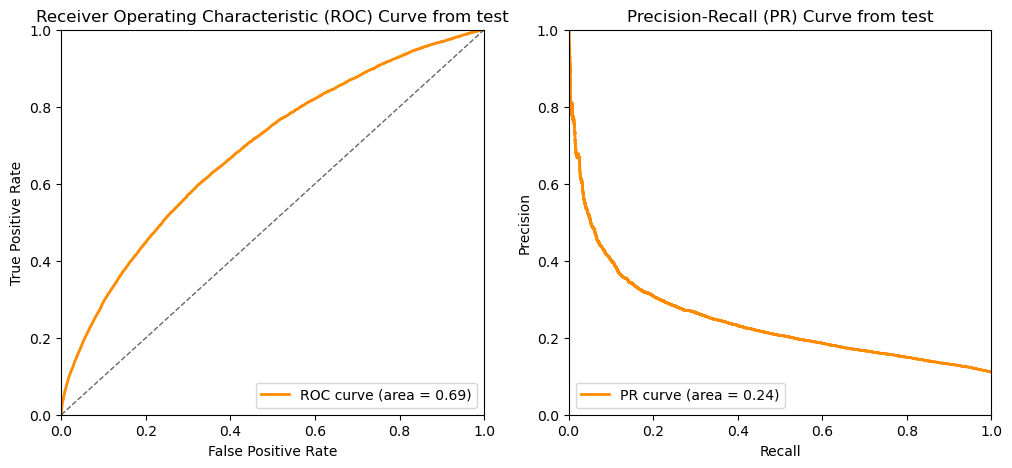

AUROC: 0.6877
AUPRC: 0.2441


[0.6876838283587183,
 0.681869842893857,
 0.6947691026347365,
 0.6183090441165273,
 0.653236914600551,
 0.613967503895081,
 0.1737847890214185,
 0.9344016676438017,
 0.27453364013951]

In [11]:
from xgboost import XGBClassifier
from ehr_models import *
import ehr_utils
import pandas as pd
from imblearn.over_sampling import SMOTE
# drop mean bayesian
fill_method = 'mean'

file_path = f'data_cleaned/ver-noelectrolyte-logtransform_{fill_method}.csv'

X_train, X_test, Y_train, Y_test = ehr_utils.get_train_test(file_path, train_size=0.8, random_state=42)
col = [
    'Gender', 'stone_history', 'Uric_WBC', 'Uric_RBC', 'Age', 'Uric_conductivity', 'Alcohol', 'Uric_bacteria', 'Hypertension', 'Systolic_BP', 'Uric_specific_gravity', 'Diabete',
    'Uric_epithelium', 'Smoke', 'Uric_PH', 'α-HBDH', 'Serum_Uric_acid', 'Creatinine', 'Basophil_percentage', 'Globulin'
]

X_train = X_train[col]
X_test = X_test[col]
model_XGBoost = XGBClassifier(n_estimators=500,
                              max_depth=6,
                              gamma=9,
                              learning_rate=0.13,
                              eval_metric='auc',
                              device='gpu',
                              subsample=0.9,
                              colsample_bytree=0.6,
                              random_state=42,
                              min_child_weight=4,
                              reg_lambda=3,
                              reg_alpha=0.9,
                              scale_pos_weight=9.0)
model_XGBoost.fit(X_train, Y_train)
print("Model training completed.")
Y_prob, Y_pred = ehr_utils.get_prediction_results(model_XGBoost, X_test)
Ytrain_prob, Ytrain_pred = ehr_utils.get_prediction_results(model_XGBoost, X_train)
ehr_utils.plot_roc_pr_curves(Y_train, Ytrain_prob, 'dt')
ehr_utils.plot_roc_pr_curves(Y_test, Y_prob, 'xgb')
ehr_utils.eval_model(Y_test, Y_prob, Y_pred)

In [12]:
with open('xgb_20fea_0.69.pkl', 'wb') as f:
    import pickle
    pickle.dump(model_XGBoost, f)